# Praktikum Pengantar Pembelajaran Mesin


---
## Bab 7. Metode Evaluasi Klasifikasi

Nama:


NIM:


Kelas:


## Membuat Fungsi-Fungsi Evaluasi yang Dibutuhkan

In [12]:
y_true = [0, 1, 2, 1, 2, 0, 1, 0, 2, 2] # Nilai sebenarnya
y_pred = [0, 1, 1, 1, 2, 0, 2, 0, 2, 1] # Prediksi
labels = [0, 1, 2] # Label kelas

In [14]:
import numpy as np

def confusion_matrix_multiclass(y_true, y_pred, labels):
  num_classes = len(labels)
  confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

  for true, pred in zip(y_true, y_pred):
    confusion_matrix[true][pred] += 1

  return confusion_matrix


def calculate_metrics(confusion_matrix, labels=None):
  num_classes = confusion_matrix.shape[0]
  metrics = {}
  total = np.sum(confusion_matrix)

  if labels is None:
    labels = list(range(num_classes))

  for i in range(num_classes):
    TP = confusion_matrix[i][i]
    FP = np.sum(confusion_matrix[:, i]) - TP
    FN = np.sum(confusion_matrix[i, :]) - TP
    TN = total - (TP + FP + FN)

    metrics[labels[i]] = {
      'TP': int(TP),
      'FP': int(FP),
      'FN': int(FN),
      'TN': int(TN)
    }

  return metrics


confusion_matrix = confusion_matrix_multiclass(y_true, y_pred, labels)
metrics = calculate_metrics(confusion_matrix, labels)

for label, metric in metrics.items():
    print(f"Class {label} - TP: {metric['TP']}, FP: {metric['FP']}, FN: {metric['FN']}, TN: {metric['TN']}")

Class 0 - TP: 3, FP: 0, FN: 0, TN: 7
Class 1 - TP: 2, FP: 2, FN: 1, TN: 5
Class 2 - TP: 2, FP: 1, FN: 2, TN: 5


In [15]:
def hitung_precision_recall_f1_accuracy(y_true, y_pred, labels):
    cm = confusion_matrix_multiclass(y_true, y_pred, labels)
    metrics = calculate_metrics(cm, labels)
    
    hasil = []
    for label, metric in metrics.items():
        precision_denom = metric['TP'] + metric['FP']
        recall_denom = metric['TP'] + metric['FN']
        
        precision = metric['TP'] / precision_denom if precision_denom != 0 else 0.0
        recall = metric['TP'] / recall_denom if recall_denom != 0 else 0.0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0.0
        accuracy_score = (metric['TP'] + metric['TN']) / (metric['TP'] + metric['FP'] + metric['FN'] + metric['TN'])
        
        hasil.append((f"Class {label} - Precision: {precision}, recall: {recall}, F1-Score: {f1_score}, accuracy: {accuracy_score}"))
    
    return hasil

display(hitung_precision_recall_f1_accuracy(y_true, y_pred, labels))

['Class 0 - Precision: 1.0, recall: 1.0, F1-Score: 1.0, accuracy: 1.0',
 'Class 1 - Precision: 0.5, recall: 0.6666666666666666, F1-Score: 0.5714285714285715, accuracy: 0.7',
 'Class 2 - Precision: 0.6666666666666666, recall: 0.5, F1-Score: 0.5714285714285715, accuracy: 0.7']

In [16]:
# Contoh data untuk roc-auc
y_true2 = [0, 1, 1, 0, 1, 0, 1, 1, 0, 0]
y_pred2 = [0.1, 0.4, 0.35, 0.8, 0.7, 0.55, 0.65, 0.9, 0.3, 0.6]

In [17]:
def calculate_tpr_fpr(y_true, y_pred, threshold):
  tp = 0
  fp = 0
  fn = 0
  tn = 0

  for i in range(len(y_true)):
    if y_pred[i] >= threshold:
      if y_true[i] == 1:
        tp += 1
      else:
        fp += 1

    else:
      if y_true[i] == 1:
        fn += 1
      else:
        tn += 1

  tpr = tp / (tp + fn)
  fpr = fp / (fp + tn)

  return tpr, fpr

In [18]:
def calculate_roc_auc(y_true, y_pred):
  thresholds = sorted(set(y_pred), reverse=True)
  roc_points = []

  for threshold in thresholds:
    tpr, fpr = calculate_tpr_fpr(y_true, y_pred, threshold)
    roc_points.append((fpr, tpr))

  # Menghitung AUC menggunakan metode trapezoid
  auc = 0.0
  for i in range(1, len(roc_points)):
    x1, y1 = roc_points[i - 1]
    x2, y2 = roc_points[i]
    auc += (x2 - x1) * (y1 + y2) / 2.0

  return roc_points, auc

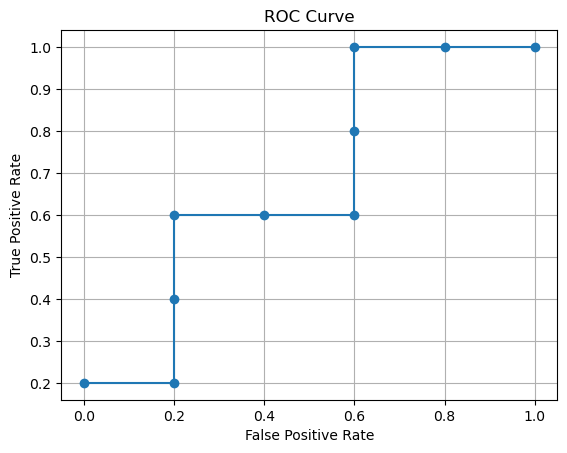

In [19]:
import matplotlib.pyplot as plt

def tampilkan_roc_curve(y_true, y_pred):
  roc_points, auc = calculate_roc_auc(y_true, y_pred)

  x, y = zip(*roc_points)
  plt.plot(x, y, marker='o')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')

  plt.grid(True)

  plt.show()

tampilkan_roc_curve(y_true2, y_pred2)

## 7.5. Tugas

1. Buatkan _method_ untuk menghitung F1-Score dan akurasi rata-rata!

In [20]:
def hitung_f1_score(y_true, y_pred, labels):
  cm = confusion_matrix_multiclass(y_true, y_pred, labels)
  metrics = calculate_metrics(cm, labels)

  f1_per_kelas = []
  for label in labels:
    metric = metrics[label]
    precision_denom = metric['TP'] + metric['FP']
    recall_denom = metric['TP'] + metric['FN']

    precision = metric['TP'] / precision_denom if precision_denom != 0 else 0.0
    recall = metric['TP'] / recall_denom if recall_denom != 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) != 0 else 0.0
    f1_per_kelas.append(f1)

  return float(np.mean(f1_per_kelas))

# print("F1-Score:", hitung_f1_score(label_uji.values, prediksi.astype(int), labels))


def hitung_accuracy_rata(y_true, y_pred, labels):
  cm = confusion_matrix_multiclass(y_true, y_pred, labels)
  metrics = calculate_metrics(cm, labels)

  accuracy_per_kelas = []
  for label in labels:
    metric = metrics[label]
    total = metric['TP'] + metric['FP'] + metric['FN'] + metric['TN']
    accuracy = (metric['TP'] + metric['TN']) / total if total != 0 else 0.0
    accuracy_per_kelas.append(accuracy)

  return float(np.mean(accuracy_per_kelas))

# print('Skor akurasi rata-rata:', hitung_accuracy_rata(label_uji.values, prediksi.astype(int), labels))

2. Buat kode program untuk menghitung MCC dari percobaan subbab 7.4!

In [21]:
def hitung_mcc(y_true, y_pred, labels):
  cm = confusion_matrix_multiclass(y_true, y_pred, labels)

  c = np.trace(cm)
  s = np.sum(cm)
  p_k = np.sum(cm, axis=0)
  t_k = np.sum(cm, axis=1)

  numerator = (c * s) - np.dot(p_k, t_k)
  denominator = np.sqrt((s**2 - np.dot(p_k, p_k)) * (s**2 - np.dot(t_k, t_k)))

  if denominator == 0:
    return 0.0

  return float(numerator / denominator)

# print('Skor MCC:', hitung_mcc(label_uji.values, prediksi.astype(int), labels))

3. Gunakan semua matriks evaluasi yang ada di bab ini untuk menghitung kinerja SVM pada _dataset_ iris yang sudah dipraktikkan pada bab sebelumnya!

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

# Menyiapkan data iris dan melatih model SVM

df_iris = pd.read_csv('data/iris_dataset.csv')
X = df_iris.drop(columns=['target'])
y = df_iris['target']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred_iris = svm_model.predict(X_test)
y_prob_iris = svm_model.predict_proba(X_test)
labels_iris = list(range(len(le.classes_)))

print('Mapping kelas:', dict(enumerate(le.classes_)))
print('Jumlah data uji:', len(y_test))

Mapping kelas: {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
Jumlah data uji: 45


Evaluasi dengan confusion matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]
==================== Pemisah ====================
Evaluasi dengan beberapa skor untuk setiap kelasnya:
Class 0 - Precision: 1.0, recall: 1.0, F1-Score: 1.0, accuracy: 1.0
Class 1 - Precision: 0.9333333333333333, recall: 0.9333333333333333, F1-Score: 0.9333333333333333, accuracy: 0.9555555555555556
Class 2 - Precision: 0.9333333333333333, recall: 0.9333333333333333, F1-Score: 0.9333333333333333, accuracy: 0.9555555555555556
F1-Score rata-rata: 0.9556
Skor akurasi rata-rata: 0.9704
==================== Pemisah ====================
Evaluasi dengan nilai AUC per kelas:
Kelas 0 (Iris-setosa): 1.0000
Kelas 1 (Iris-versicolor): 0.9933
Kelas 2 (Iris-virginica): 0.9933
AUC rata-rata (macro): 0.9956
Menampilkan ROC curve kelas 0 (Iris-setosa) vs lainnya


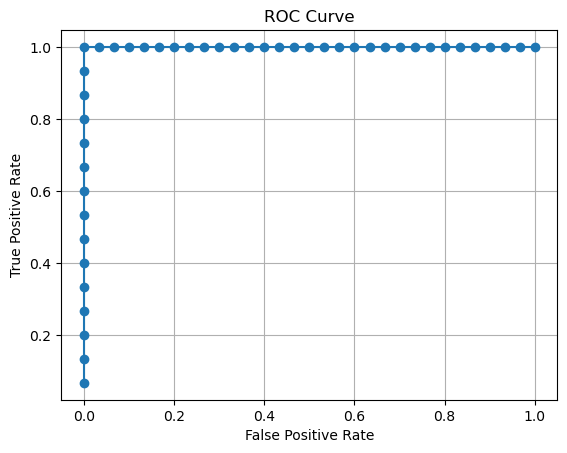

==================== Pemisah ====================
Evaluasi dengan skor MCC:
Skor MCC: 0.9333


In [23]:
# Evaluasi dengan metode Confusion Matrix
print('Evaluasi dengan confusion matrix:')
cm_iris = confusion_matrix_multiclass(y_test, y_pred_iris, labels_iris)
print(cm_iris)

print('==================== Pemisah ====================')

# Evaluasi dengan metode Precision, Recall, F1, dan Accuracy
print('Evaluasi dengan beberapa skor untuk setiap kelasnya:')
for ringkasan in hitung_precision_recall_f1_accuracy(y_test, y_pred_iris, labels_iris):
  print(ringkasan)

f1_rata = hitung_f1_score(y_test, y_pred_iris, labels_iris)
akurasi_rata = hitung_accuracy_rata(y_test, y_pred_iris, labels_iris)
print(f'F1-Score rata-rata: {f1_rata:.4f}')
print(f'Skor akurasi rata-rata: {akurasi_rata:.4f}')

print('==================== Pemisah ====================')

# Evaluasi dengan menghitung ROC dan AUC (One-vs-Rest per kelas)
auc_per_kelas = {}
for label in labels_iris:
  y_true_biner = [1 if y_val == label else 0 for y_val in y_test]
  y_score_biner = y_prob_iris[:, label].tolist()
  roc_points, auc = calculate_roc_auc(y_true_biner, y_score_biner)
  auc_per_kelas[label] = auc

print('Evaluasi dengan nilai AUC per kelas:')
for label, auc in auc_per_kelas.items():
  print(f'Kelas {label} ({le.classes_[label]}): {auc:.4f}')
print(f"AUC rata-rata (macro): {np.mean(list(auc_per_kelas.values())):.4f}")

contoh_kelas = labels_iris[0]
print(f"Menampilkan ROC curve kelas {contoh_kelas} ({le.classes_[contoh_kelas]}) vs lainnya")
tampilkan_roc_curve(
  [1 if y_val == contoh_kelas else 0 for y_val in y_test],
  y_prob_iris[:, contoh_kelas].tolist()
)

print('==================== Pemisah ====================')

# Evaluasi dengan menghitung MCC
print('Evaluasi dengan skor MCC:')
print(f"Skor MCC: {hitung_mcc(y_test, y_pred_iris, labels_iris):.4f}")

## 7.6. Kesimpulan

Kesimpulan apa yang kamu dapatkan selama praktikum Modul 7 ini, menjawab dari pertanyaan-pertanyaan di bawah ini:
1. Apakah tujuan percobaan telah tercapai?
2. Apa hubungan antara hasil percobaan dan dasar teori?
3. Faktor-faktor apa saja yang memengaruhi hasil percobaan, termasuk kemungkinan kesalahan yang terjadi?

Isi dengan kesimpulan ...